In [1]:
# ─── Environment Setup (do not edit) ────────────────────────────────────────
import os, sys
from pathlib import Path


def _detect_platform():
    try:
        import google.colab  # noqa: F401

        return "colab", False
    except ImportError:
        pass
    if Path("/workspace").exists() and os.environ.get("VAST_CONTAINERLABEL"):
        return "vastai", False
    if Path("/workspace").exists():
        return "vastai", True
    if sys.platform == "win32":
        return "windows", False
    if sys.platform == "darwin":
        return "mac", False
    return None, True


PLATFORM, _uncertain = _detect_platform()

if PLATFORM == "colab":
    from google.colab import drive

    drive.mount("/content/drive")

try:
    _nb_path = Path(__file__).resolve()
except NameError:
    _nb_path = Path.cwd()

if PLATFORM == "colab":
    PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis_Final/fake-news-detection")
else:
    PROJECT_ROOT = _nb_path.parents[1]

sys.path.insert(0, str(PROJECT_ROOT))

_env_map = {
    "colab": PROJECT_ROOT / ".env.colab",
    "vastai": PROJECT_ROOT / ".env.vastai",
    "windows": PROJECT_ROOT / ".env.windows",
    "mac": PROJECT_ROOT / ".env.mac",
}

if PLATFORM is None:
    print("⚠️  WARNING: Could not detect platform. Falling back to .env (local).")
    _env_file = PROJECT_ROOT / ".env"
elif _uncertain:
    print(
        f"⚠️  WARNING: Detected /workspace but VAST_CONTAINERLABEL is not set. Assuming Vast.ai."
    )
    _env_file = _env_map["vastai"]
else:
    _env_file = _env_map[PLATFORM]

from dotenv import load_dotenv

if not _env_file.exists():
    _fallback = PROJECT_ROOT / ".env"
    print(f"⚠️  WARNING: Expected env file not found: {_env_file}")
    if _fallback.exists():
        print(f"   Falling back to: {_fallback}")
        _env_file = _fallback
    else:
        raise FileNotFoundError(
            f"No .env file found. Copy the correct example file:\n"
            f"  cp .env.{PLATFORM or 'mac'}.example .env.{PLATFORM or 'mac'}"
        )

load_dotenv(_env_file, override=True)

from src.utils.env_utils import get_data_root

DATA_ROOT = get_data_root()

print(f"✅ Platform : {PLATFORM or 'unknown (local fallback)'}")
print(f"✅ Env file : {_env_file}")
print(f"✅ DATA_ROOT: {DATA_ROOT}")
print(f"{'✅' if DATA_ROOT.exists() else '❌'} Path exists: {DATA_ROOT.exists()}")
# ─────────────────────────────────────────────────────────────────────────────

✅ Platform : mac
✅ Env file : /Users/haila/My File/projects/fake-new-detection/.env.mac
✅ DATA_ROOT: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis
✅ Path exists: True


# AI-Generated Art Detection — Stage 3.5

Fine-tunes a small classifier head on frozen CLIP ViT-L/14 image features to distinguish
**real artwork** (WikiArt) from **AI/GAN-generated images**, using the HuggingFace dataset
`hmnshudhmn24/real-fake-ai-generated-art-images` (21,642 images, balanced REAL/FAKE).

This produces a standalone "is this image AI-generated" detector — a useful auxiliary signal
for fake-news detection, since AI-generated images are a common misinformation artifact.
Stage 3.6 turns the trained checkpoint into a per-image signal for the COOLANT pipeline.

```
Input:  hmnshudhmn24/real-fake-ai-generated-art-images (HF, single 'train' split)
Output: training/checkpoints_ai_art/<run>/best_model.pth
        training/checkpoints_ai_art/<run>/checkpoint_manifest.json  ← Stage 3.6 handoff
```


In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────
# All tunable parameters and paths live here. Edit this cell only.
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == "pipeline" else Path.cwd()

try:
    from dotenv import load_dotenv

    load_dotenv(PROJECT_ROOT / ".env", override=False)
except ImportError:
    pass

DATA_ROOT = (
    Path(os.environ["DATA_ROOT"]) if os.environ.get("DATA_ROOT") else PROJECT_ROOT
)

CONFIG = {
    "paths": {
        "checkpoint_root": DATA_ROOT / "training" / "checkpoints_ai_art",
        # Cached CLIP features so we don't re-extract on every run
        "features_cache_dir": DATA_ROOT / "training" / "ai_art_features",
        "mlflow_dir": DATA_ROOT / "mlruns",
    },
    "data": {
        "hf_dataset": "hmnshudhmn24/real-fake-ai-generated-art-images",
        "hf_image_field": "image",
        # None = auto-detect from dataset columns; or set manually
        "hf_label_field": None,
        # Dataset ships a single 'train' split -> stratified split ourselves
        "val_fraction": 0.1,
        "test_fraction": 0.1,
    },
    "model": {
        "backbone": "clip-vit-L-14",  # registered in src/preprocessing/image_preprocessing.py
        "feature_dim": 1024,
        "hidden_dim": 256,
        "dropout": 0.2,
    },
    "training": {
        "batch_size": 32,
        "max_epochs": 15,
        "patience": 5,
        "lr": 1e-3,
        "weight_decay": 0.01,
        "grad_clip": 1.0,
        "seed": 42,
    },
    "mlflow": {
        "experiment_name": "ai-art-detection-stage35",
    },
    "safety": {
        "smoke_test": False,
        "smoke_n_samples": 200,
        "auto_install_deps": False,
        "resume_from_checkpoint": None,
        "force_rebuild_features": False,
    },
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root:    {DATA_ROOT}")
print(f"Checkpoint root: {CONFIG['paths']['checkpoint_root']}")
print(f"Feature cache:   {CONFIG['paths']['features_cache_dir']}")

Project root: /Users/haila/My File/projects/fake-new-detection
Data root:    /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis
Checkpoint root: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_ai_art
Feature cache:   /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/ai_art_features


In [3]:
# ── DEPENDENCY PREFLIGHT ────────────────────────────────────────────────────
import importlib, sys

_required = {
    "torch": "torch",
    "torchvision": "torchvision",
    "transformers": "transformers",
    "datasets": "datasets",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "tqdm": "tqdm",
    "sklearn": "scikit-learn",
    "mlflow": "mlflow",
    "PIL": "pillow",
}

_missing = []
for mod, pkg in _required.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        _missing.append(pkg)

if _missing:
    if CONFIG["safety"]["auto_install_deps"]:
        import subprocess

        subprocess.check_call([sys.executable, "-m", "pip", "install"] + _missing)
        print(f"Installed: {_missing}")
    else:
        print(f"Missing packages: {_missing}")
        print("Install with:  pip install " + " ".join(_missing))
        raise RuntimeError(f"Missing packages: {_missing}.")
else:
    print("All dependencies satisfied.")

All dependencies satisfied.


In [4]:
# ── IMPORTS AND SETUP ───────────────────────────────────────────────────────
import sys, os, gc, json, random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.image_preprocessing import ImagePreprocessor

CONFIG["paths"]["checkpoint_root"].mkdir(parents=True, exist_ok=True)
CONFIG["paths"]["features_cache_dir"].mkdir(parents=True, exist_ok=True)

print(f"PyTorch : {torch.__version__}")


def select_device():
    if torch.cuda.is_available():
        dev = torch.device("cuda")
        mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"Device: cuda ({torch.cuda.get_device_name(0)}, {mem:.1f} GB)")
    elif torch.backends.mps.is_available():
        dev = torch.device("mps")
        print("Device: mps (Apple Silicon). For full training, prefer a CUDA GPU.")
    else:
        dev = torch.device("cpu")
        print("Device: cpu. Use smoke_test=True for local validation.")
    return dev


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    print(f"Seed: {seed}")


DEVICE = select_device()
seed_everything(CONFIG["training"]["seed"])

PyTorch : 2.12.0
Device: mps (Apple Silicon). For full training, prefer a CUDA GPU.
Seed: 42


## Step 1: Load AI-Art Dataset From HuggingFace

Loads `hmnshudhmn24/real-fake-ai-generated-art-images` (single `train` split, 21,642 images,
balanced REAL/FAKE). Auto-detects the label column, then does a stratified train/val/test
split ourselves since the dataset ships only one split.


In [5]:
def _detect_label_field(sample):
    lbl_cands = ["label", "labels", "Label", "class", "category"]
    return next((f for f in lbl_cands if f in sample), None)


def _normalize_label(raw_label, label_names):
    """Map raw label (int class-id or string) to binary: 0=Real, 1=Fake(AI-generated)."""
    if isinstance(raw_label, str):
        text = raw_label.strip().upper()
        if "FAKE" in text or "AI" in text or "GAN" in text:
            return 1
        if "REAL" in text:
            return 0
        raise ValueError(f"Cannot map string label {raw_label!r} to Real/Fake.")
    idx = int(raw_label)
    if label_names:
        name = label_names[idx].strip().upper()
        if "FAKE" in name or "AI" in name or "GAN" in name:
            return 1
        if "REAL" in name:
            return 0
    return idx


def load_ai_art_dataset(config):
    from datasets import load_dataset, concatenate_datasets

    hf_name = config["data"]["hf_dataset"]
    print(f"Loading '{hf_name}' from HuggingFace...")
    raw = load_dataset(hf_name, split="train")
    print(f"  Columns : {raw.column_names}")

    # datasets 5.x PackagedDatasetModuleFactory calls Path(data_dir).resolve()
    # which corrupts hf:// URLs into local paths. Work around by loading
    # Data/REAL and Data/FAKE as separate splits (stays in HubDatasetModuleFactory
    # which handles hub paths correctly), then add labels and concatenate.
    if "label" not in raw.column_names:
        print(
            "  No label column — loading Data/REAL and Data/FAKE separately via hub data_dir..."
        )
        real_ds = load_dataset(hf_name, data_dir="Data/REAL", split="train")
        real_ds = real_ds.add_column("label", [0] * len(real_ds))
        fake_ds = load_dataset(hf_name, data_dir="Data/FAKE", split="train")
        fake_ds = fake_ds.add_column("label", [1] * len(fake_ds))
        raw = concatenate_datasets([real_ds, fake_ds])
        print(f"  REAL: {len(real_ds)}  FAKE: {len(fake_ds)}  Total: {len(raw)}")
        print(f"  Columns after reload: {raw.column_names}")

    image_field = config["data"]["hf_image_field"]
    label_field = config["data"]["hf_label_field"] or _detect_label_field(dict(raw[0]))
    if label_field is None:
        raise ValueError(
            f"Cannot auto-detect label field from columns {raw.column_names}.\n"
            f"Set CONFIG['data']['hf_label_field'] manually."
        )
    print(f"  image_field = {image_field!r}")
    print(f"  label_field = {label_field!r}")

    label_names = None
    feat = raw.features.get(label_field)
    if hasattr(feat, "names"):
        label_names = feat.names
        print(f"  label_names = {label_names}")

    labels = np.array(
        [_normalize_label(v, label_names) for v in raw[label_field]], dtype=np.int64
    )
    hist = np.bincount(labels, minlength=2).tolist()
    print(f"  Total: {len(labels)} samples | label dist (Real, Fake): {hist}")
    return raw, labels, image_field


def stratified_split(n, labels, val_frac, test_frac, seed):
    rng = np.random.RandomState(seed)
    train_idx, val_idx, test_idx = [], [], []
    for cls in np.unique(labels):
        cls_idx = np.where(labels == cls)[0]
        rng.shuffle(cls_idx)
        n_val = int(len(cls_idx) * val_frac)
        n_test = int(len(cls_idx) * test_frac)
        val_idx.extend(cls_idx[:n_val])
        test_idx.extend(cls_idx[n_val : n_val + n_test])
        train_idx.extend(cls_idx[n_val + n_test :])
    return (
        np.array(sorted(train_idx)),
        np.array(sorted(val_idx)),
        np.array(sorted(test_idx)),
    )


raw_dataset, all_labels, IMAGE_FIELD = load_ai_art_dataset(CONFIG)

if CONFIG["safety"]["smoke_test"]:
    _n = CONFIG["safety"]["smoke_n_samples"]
    _rng = np.random.RandomState(CONFIG["training"]["seed"])
    _idx = _rng.choice(len(all_labels), size=min(_n, len(all_labels)), replace=False)
    raw_dataset = raw_dataset.select(_idx.tolist())
    all_labels = all_labels[_idx]
    print(f"SMOKE TEST: subsampled to {len(all_labels)} images")

train_idx, val_idx, test_idx = stratified_split(
    len(all_labels),
    all_labels,
    CONFIG["data"]["val_fraction"],
    CONFIG["data"]["test_fraction"],
    CONFIG["training"]["seed"],
)
split_indices = {"train": train_idx, "val": val_idx, "test": test_idx}
for split, idx in split_indices.items():
    hist = np.bincount(all_labels[idx], minlength=2).tolist()
    print(f"  {split:5s}: {len(idx):6d} samples | label dist (Real, Fake): {hist}")

Loading 'hmnshudhmn24/real-fake-ai-generated-art-images' from HuggingFace...


Resolving data files:   0%|          | 0/9365 [00:00<?, ?it/s]

  Columns : ['image']
  No label column — loading Data/REAL and Data/FAKE separately via hub data_dir...


Using the latest cached version of the dataset since hmnshudhmn24/real-fake-ai-generated-art-images couldn't be found on the Hugging Face Hub
Using the latest cached version of the dataset since hmnshudhmn24/real-fake-ai-generated-art-images couldn't be found on the Hugging Face Hub


ValueError: Couldn't find cache for hmnshudhmn24/real-fake-ai-generated-art-images for config 'default-data_dir=Data%2FREAL'
Available configs in the cache: ['default', 'default-38e172ae4d6394b0']

## Step 2: Extract Frozen CLIP Features

Uses `ImagePreprocessor(model_name="clip-vit-L-14")` (already registered in
`src/preprocessing/image_preprocessing.py`) to extract 1024-dim CLIP ViT-L/14 features once,
caching them to `.npz` so re-running the notebook doesn't re-extract.


In [ ]:
image_preprocessor = ImagePreprocessor(
    model_name=CONFIG["model"]["backbone"], device=str(DEVICE)
)
print(
    f"Backbone: {CONFIG['model']['backbone']}  feature_dim: {image_preprocessor.feature_dim}"
)


def extract_or_load_features(
    split, indices, dataset, labels, image_field, preprocessor, config
):
    cache_path = config["paths"]["features_cache_dir"] / f"{split}.npz"
    if cache_path.exists() and not config["safety"]["force_rebuild_features"]:
        loaded = np.load(cache_path)
        print(
            f"  [cache] {split}: loaded {loaded['data'].shape[0]} features from {cache_path.name}"
        )
        return loaded["data"], loaded["label"]

    images = [dataset[int(i)][image_field] for i in indices]
    split_labels = labels[indices]
    features = preprocessor.extract_features_from_images(images)
    preprocessor.save_preprocessed_data(features, split_labels, str(cache_path))
    return features, split_labels


features_by_split, labels_by_split = {}, {}
for split, idx in split_indices.items():
    feats, lbls = extract_or_load_features(
        split, idx, raw_dataset, all_labels, IMAGE_FIELD, image_preprocessor, CONFIG
    )
    features_by_split[split] = feats
    labels_by_split[split] = lbls
    print(f"  {split:5s}: features {feats.shape}  labels {lbls.shape}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_a

Backbone: clip-vit-L-14  feature_dim: 1024
  [cache] train: loaded 7493 features from train.npz
  train: features (7493, 1024)  labels (7493,)
  [cache] val: loaded 936 features from val.npz
  val  : features (936, 1024)  labels (936,)
  [cache] test: loaded 936 features from test.npz
  test : features (936, 1024)  labels (936,)


## Step 3: Build DataLoaders

Wraps cached CLIP features in the existing `ImageDataset` (from `image_preprocessing.py`).


In [ ]:
from src.preprocessing.image_preprocessing import ImageDataset

_bs = CONFIG["training"]["batch_size"]

datasets_map = {
    split: ImageDataset(features_by_split[split], labels_by_split[split])
    for split in ["train", "val", "test"]
}

loaders = {
    "train": DataLoader(
        datasets_map["train"], batch_size=_bs, shuffle=True, num_workers=0
    ),
    "val": DataLoader(
        datasets_map["val"], batch_size=_bs, shuffle=False, num_workers=0
    ),
    "test": DataLoader(
        datasets_map["test"], batch_size=_bs, shuffle=False, num_workers=0
    ),
}

_b = next(iter(loaders["train"]))
print(f"Batch shapes — features: {tuple(_b[0].shape)}  labels: {tuple(_b[1].shape)}")

Batch shapes — features: (32, 1024)  labels: (32,)


## Step 4: Build Classifier Head

Small MLP head (frozen CLIP features → 256 → 1 logit). CLIP backbone stays frozen —
only the head is trained, matching the frozen-encoder convention used in Stage 3.9.


In [ ]:
class AIArtClassifierHead(nn.Module):
    """Binary classifier head on frozen CLIP image features. 0=Real, 1=AI-generated."""

    def __init__(self, feature_dim, hidden_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, features):
        return self.net(features).squeeze(-1)  # [B] logit


model = AIArtClassifierHead(
    feature_dim=CONFIG["model"]["feature_dim"],
    hidden_dim=CONFIG["model"]["hidden_dim"],
    dropout=CONFIG["model"]["dropout"],
).to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f"Classifier head parameters: {total:,}")

model.eval()
with torch.no_grad():
    _logit = model(_b[0][:2].to(DEVICE))
print(f"Sanity forward output shape: {tuple(_logit.shape)}  (expected [2])")

Classifier head parameters: 262,657
Sanity forward output shape: (2,)  (expected [2])


## Step 5: Loss, Optimizer, MLflow


In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["training"]["lr"],
    weight_decay=CONFIG["training"]["weight_decay"],
)

import mlflow

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_name = f"ai_art_stage35_{timestamp}"

run_dir = CONFIG["paths"]["checkpoint_root"] / run_name
artifact_dir = run_dir / "artifacts"
run_dir.mkdir(parents=True, exist_ok=True)
artifact_dir.mkdir(parents=True, exist_ok=True)
print(f"Run dir: {run_dir}")

mlflow_enabled = False
mlflow_run_id = None
try:
    mlflow.set_tracking_uri(CONFIG["paths"]["mlflow_dir"].as_uri())
    mlflow.set_experiment(CONFIG["mlflow"]["experiment_name"])
    _mlflow_run = mlflow.start_run(run_name=run_name)
    mlflow_run_id = _mlflow_run.info.run_id
    mlflow.log_params(
        {
            "backbone": CONFIG["model"]["backbone"],
            "batch_size": CONFIG["training"]["batch_size"],
            "max_epochs": CONFIG["training"]["max_epochs"],
            "lr": CONFIG["training"]["lr"],
            "patience": CONFIG["training"]["patience"],
            "smoke_test": CONFIG["safety"]["smoke_test"],
            "seed": CONFIG["training"]["seed"],
        }
    )
    mlflow_enabled = True
    print(f"MLflow run: {mlflow_run_id}")
except Exception as _mlf_err:
    print(f"MLflow disabled; continuing with local artifacts only ({_mlf_err})")

Run dir: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_ai_art/ai_art_stage35_20260708_222634
MLflow disabled; continuing with local artifacts only (The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.)


## Step 6: Training and Evaluation Functions


In [ ]:
def compute_metrics(y_true, y_pred, prefix):
    return {
        f"{prefix}_accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        f"{prefix}_f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        f"{prefix}_precision": round(
            float(precision_score(y_true, y_pred, zero_division=0)), 4
        ),
        f"{prefix}_recall": round(
            float(recall_score(y_true, y_pred, zero_division=0)), 4
        ),
    }


def run_epoch(model, loader, loss_fn, optimizer, device, config, train):
    model.train() if train else model.eval()
    total_loss, n_batches = 0.0, 0
    y_true_all, y_pred_all = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        pbar = tqdm(loader, desc="  train" if train else "  eval", leave=False)
        for features, labels in pbar:
            features = features.to(device)
            labels = labels.to(device).float()

            logits = model(features)
            loss = loss_fn(logits, labels)

            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite loss: {loss.item()}")

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), config["training"]["grad_clip"]
                )
                optimizer.step()
                optimizer.zero_grad()

            total_loss += loss.item()
            n_batches += 1
            preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy()
            y_pred_all.extend(preds.tolist())
            y_true_all.extend(labels.long().cpu().numpy().tolist())
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    mean_loss = total_loss / max(1, n_batches)
    return mean_loss, np.array(y_true_all), np.array(y_pred_all)


def save_checkpoint(path, model, epoch, metrics, config, history, mlflow_run_id=None):
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "metrics": metrics,
            "training_history": history,
            "backbone": config["model"]["backbone"],
            "feature_dim": config["model"]["feature_dim"],
            "hidden_dim": config["model"]["hidden_dim"],
            "dropout": config["model"]["dropout"],
            "mlflow_run_id": mlflow_run_id,
        },
        path,
    )


print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## Step 7: Run Training

Epoch loop with early stopping on `val_f1`. Best checkpoint saved to `run_dir/best_model.pth`.


In [ ]:
patience = CONFIG["training"]["patience"]
max_epochs = CONFIG["training"]["max_epochs"]
best_val_f1 = -1.0
best_epoch = -1
no_improve = 0
history = []
best_ckpt_path = run_dir / "best_model.pth"

_resume = CONFIG["safety"]["resume_from_checkpoint"]
start_epoch = 0
if _resume and Path(_resume).exists():
    _ckpt = torch.load(_resume, map_location=DEVICE)
    model.load_state_dict(_ckpt["model_state_dict"])
    start_epoch = _ckpt.get("epoch", 0) + 1
    print(f"Resumed from epoch {_ckpt.get('epoch', '?')}: {_resume}")

print(f"Training for up to {max_epochs} epochs (patience={patience})...")
print(f"Best checkpoint → {best_ckpt_path}\n")

try:
    for epoch in range(start_epoch, max_epochs):
        train_loss, y_tr, yp_tr = run_epoch(
            model, loaders["train"], loss_fn, optimizer, DEVICE, CONFIG, train=True
        )
        train_metrics = compute_metrics(y_tr, yp_tr, "train")
        train_metrics["train_loss"] = round(train_loss, 4)

        val_loss, y_vl, yp_vl = run_epoch(
            model, loaders["val"], loss_fn, None, DEVICE, CONFIG, train=False
        )
        val_metrics = compute_metrics(y_vl, yp_vl, "val")
        val_metrics["val_loss"] = round(val_loss, 4)
        val_metrics["val_confusion_matrix"] = confusion_matrix(
            y_vl, yp_vl, labels=[0, 1]
        ).tolist()

        epoch_record = {"epoch": epoch, **train_metrics, **val_metrics}
        history.append(epoch_record)

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f}  train_acc={train_metrics['train_accuracy']:.4f}  "
            f"train_f1={train_metrics['train_f1']:.4f} | "
            f"val_loss={val_loss:.4f}  val_acc={val_metrics['val_accuracy']:.4f}  "
            f"val_f1={val_metrics['val_f1']:.4f}"
        )

        if mlflow_enabled:
            mlflow.log_metrics(
                {
                    "train_loss": train_loss,
                    "train_acc": train_metrics["train_accuracy"],
                    "train_f1": train_metrics["train_f1"],
                    "val_loss": val_loss,
                    "val_acc": val_metrics["val_accuracy"],
                    "val_f1": val_metrics["val_f1"],
                },
                step=epoch,
            )

        val_f1 = val_metrics["val_f1"]
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            no_improve = 0
            save_checkpoint(
                best_ckpt_path,
                model,
                epoch,
                {**train_metrics, **val_metrics},
                CONFIG,
                history,
                mlflow_run_id,
            )
            print(f"  ✅ New best val_f1={best_val_f1:.4f} → saved checkpoint")
        else:
            no_improve += 1
            print(f"  No improvement ({no_improve}/{patience})")
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}.")
                break

        with open(artifact_dir / "training_history.json", "w") as f:
            json.dump(history, f, indent=2)

        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

except KeyboardInterrupt:
    print("Training interrupted by user.")

print(f"\nTraining complete. Best epoch: {best_epoch}  val_f1: {best_val_f1:.4f}")

with open(artifact_dir / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)
print(f"Training history saved: {artifact_dir / 'training_history.json'}")

if mlflow_enabled:
    try:
        mlflow.end_run()
    except Exception:
        pass

Training for up to 15 epochs (patience=5)...
Best checkpoint → /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_ai_art/ai_art_stage35_20260708_222634/best_model.pth



  train:   0%|          | 0/235 [00:00<?, ?it/s]

  eval:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 00 | train_loss=0.0047  train_acc=0.9959  train_f1=0.9979 | val_loss=0.0000  val_acc=1.0000  val_f1=1.0000
  ✅ New best val_f1=1.0000 → saved checkpoint


  train:   0%|          | 0/235 [00:00<?, ?it/s]

...

  eval:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0000  train_acc=1.0000  train_f1=1.0000 | val_loss=0.0000  val_acc=1.0000  val_f1=1.0000
  No improvement (4/5)


  train:   0%|          | 0/235 [00:00<?, ?it/s]

  eval:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0000  train_acc=1.0000  train_f1=1.0000 | val_loss=0.0000  val_acc=1.0000  val_f1=1.0000
  No improvement (5/5)
Early stopping at epoch 5.

Training complete. Best epoch: 0  val_f1: 1.0000
Training history saved: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_ai_art/ai_art_stage35_20260708_222634/artifacts/training_history.json


## Step 8: Final Test Evaluation


In [ ]:
if not best_ckpt_path.exists():
    print("⚠  best_model.pth not found — skipping test evaluation.")
else:
    _ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(_ckpt["model_state_dict"])
    print(f"Loaded best checkpoint (epoch {_ckpt['epoch']}) for test evaluation.")

    test_loss, y_te, yp_te = run_epoch(
        model, loaders["test"], loss_fn, None, DEVICE, CONFIG, train=False
    )
    test_metrics = compute_metrics(y_te, yp_te, "test")
    test_metrics["test_loss"] = round(test_loss, 4)

    cm_test = confusion_matrix(y_te, yp_te, labels=[0, 1])

    print(f"\n{'='*55}")
    print(f"TEST RESULTS  (best epoch: {best_epoch})")
    print(f"{'='*55}")
    for k, v in test_metrics.items():
        print(f"  {k:<20s}: {v}")
    print(f"  Confusion matrix (rows=true, cols=pred) [Real, Fake]:\n{cm_test}")

    test_report = {
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        **test_metrics,
        "confusion_matrix": cm_test.tolist(),
        "label_names": {0: "Real", 1: "Fake"},
    }
    with open(artifact_dir / "test_report.json", "w") as f:
        json.dump(test_report, f, indent=2)
    print(f"\nTest report saved: {artifact_dir / 'test_report.json'}")

Loaded best checkpoint (epoch 0) for test evaluation.


  eval:   0%|          | 0/30 [00:00<?, ?it/s]


TEST RESULTS  (best epoch: 0)
  test_accuracy       : 1.0
  test_f1             : 1.0
  test_precision      : 1.0
  test_recall         : 1.0
  test_loss           : 0.0
  Confusion matrix (rows=true, cols=pred) [Real, Fake]:
[[  0   0]
 [  0 936]]

Test report saved: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_ai_art/ai_art_stage35_20260708_222634/artifacts/test_report.json


## Step 9: Visualize Training Curves and Confusion Matrix


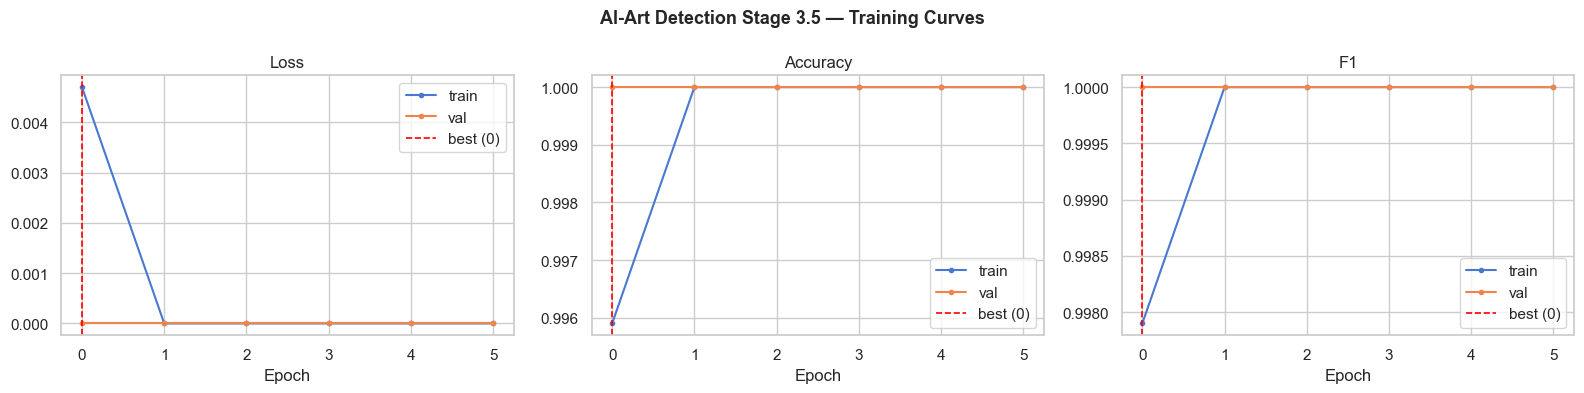

/var/folders/rh/5t55t1152fjbnbkbpyk4_t6c0000gn/T/ipykernel_35855/4036036523.py:51: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)


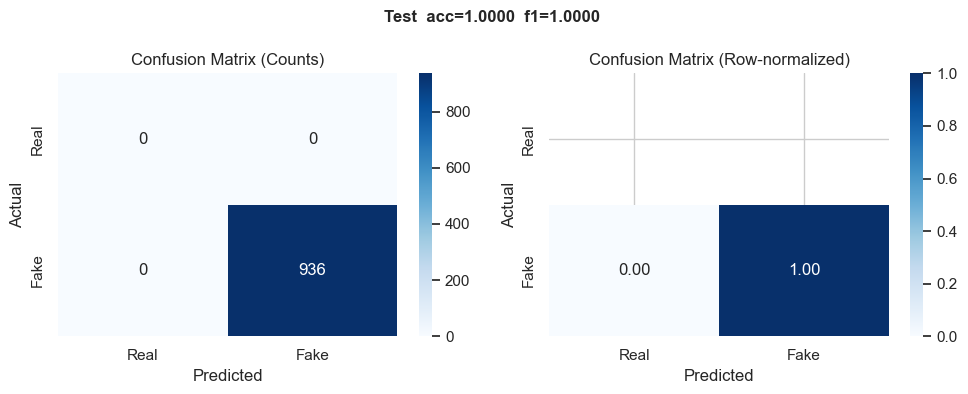

In [ ]:
if not history:
    print("No training history to plot.")
else:
    sns.set_theme(style="whitegrid", palette="muted")
    hist_df = pd.DataFrame(history)
    epochs = hist_df["epoch"]
    best_ep = best_epoch

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    def _vline(ax):
        ax.axvline(
            best_ep,
            color="red",
            linestyle="--",
            linewidth=1.2,
            label=f"best ({best_ep})",
        )

    axes[0].plot(epochs, hist_df["train_loss"], label="train", marker="o", markersize=3)
    axes[0].plot(epochs, hist_df["val_loss"], label="val", marker="o", markersize=3)
    _vline(axes[0])
    axes[0].set_title("Loss")
    axes[0].legend()

    axes[1].plot(
        epochs, hist_df["train_accuracy"], label="train", marker="o", markersize=3
    )
    axes[1].plot(epochs, hist_df["val_accuracy"], label="val", marker="o", markersize=3)
    _vline(axes[1])
    axes[1].set_title("Accuracy")
    axes[1].legend()

    axes[2].plot(epochs, hist_df["train_f1"], label="train", marker="o", markersize=3)
    axes[2].plot(epochs, hist_df["val_f1"], label="val", marker="o", markersize=3)
    _vline(axes[2])
    axes[2].set_title("F1")
    axes[2].legend()

    for ax in axes:
        ax.set_xlabel("Epoch")
    plt.suptitle(
        "AI-Art Detection Stage 3.5 — Training Curves", fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(artifact_dir / "training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

    if best_ckpt_path.exists():
        labels_plot = ["Real", "Fake"]
        cm_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        for ax, data, fmt, title in zip(
            axes, [cm_test, cm_norm], ["d", ".2f"], ["Counts", "Row-normalized"]
        ):
            sns.heatmap(
                data,
                annot=True,
                fmt=fmt,
                cmap="Blues",
                xticklabels=labels_plot,
                yticklabels=labels_plot,
                ax=ax,
                vmin=0 if fmt == ".2f" else None,
                vmax=1 if fmt == ".2f" else None,
            )
            ax.set_xlabel("Predicted")
            ax.set_ylabel("Actual")
            ax.set_title(f"Confusion Matrix ({title})")

        plt.suptitle(
            f"Test  acc={test_metrics['test_accuracy']:.4f}  f1={test_metrics['test_f1']:.4f}",
            fontsize=12,
            fontweight="bold",
        )
        plt.tight_layout()
        plt.savefig(
            artifact_dir / "test_confusion_matrix.png", dpi=150, bbox_inches="tight"
        )
        plt.show()

## Step 10: Write Checkpoint Manifest (Stage 3.6 Handoff)

Stage 3.6 loads this manifest to run the frozen classifier over COOLANT news images and
produce an `ai_generated_score` signal.


In [ ]:
def write_checkpoint_manifest(
    manifest_path,
    best_ckpt_path,
    best_epoch,
    best_metrics,
    config,
    mlflow_enabled,
    mlflow_run_id,
):
    manifest = {
        "best_checkpoint_path": str(best_ckpt_path),
        "best_epoch": best_epoch,
        "selection_metric": "val_f1",
        "best_metrics": best_metrics,
        "backbone": config["model"]["backbone"],
        "feature_dim": config["model"]["feature_dim"],
        "hidden_dim": config["model"]["hidden_dim"],
        "dropout": config["model"]["dropout"],
        "label_names": {"0": "Real", "1": "Fake"},
        "mlflow_enabled": mlflow_enabled,
        "mlflow_run_id": mlflow_run_id,
        "stage36_integration": {
            "description": (
                "Stage 3.6 loads this checkpoint, extracts CLIP ViT-L/14 features from "
                "COOLANT news images, runs them through AIArtClassifierHead, and saves "
                "a per-image ai_generated_score signal."
            ),
            "usage": (
                "ckpt = torch.load(best_checkpoint_path); "
                "head = AIArtClassifierHead(ckpt['feature_dim'], ckpt['hidden_dim'], ckpt['dropout']); "
                "head.load_state_dict(ckpt['model_state_dict']); head.eval(); "
                "score = torch.sigmoid(head(clip_features))  # [B] in [0, 1]"
            ),
        },
    }
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2)
    print(f"Manifest written: {manifest_path}")


if best_ckpt_path.exists():
    manifest_path = run_dir / "checkpoint_manifest.json"
    best_metrics_for_manifest = {"best_val_f1": best_val_f1, "best_epoch": best_epoch}
    if "test_metrics" in dir() and test_metrics:
        best_metrics_for_manifest.update(
            {
                "test_accuracy": test_metrics.get("test_accuracy"),
                "test_f1": test_metrics.get("test_f1"),
                "test_precision": test_metrics.get("test_precision"),
                "test_recall": test_metrics.get("test_recall"),
            }
        )
    write_checkpoint_manifest(
        manifest_path,
        best_ckpt_path,
        best_epoch,
        best_metrics_for_manifest,
        CONFIG,
        mlflow_enabled,
        mlflow_run_id,
    )

    print(f"\n{'='*60}")
    print("Stage 3.5 complete. Outputs:")
    print(f"  Best checkpoint : {best_ckpt_path}")
    print(f"  Manifest        : {manifest_path}")
    print(f"  Artifacts       : {artifact_dir}")
    print(f"\nStage 3.6 handoff manifest path: {manifest_path}")
else:
    print("⚠  No checkpoint found. Training may not have completed successfully.")

Manifest written: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_ai_art/ai_art_stage35_20260708_222634/checkpoint_manifest.json

Stage 3.5 complete. Outputs:
  Best checkpoint : /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_ai_art/ai_art_stage35_20260708_222634/best_model.pth
  Manifest        : /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_ai_art/ai_art_stage35_20260708_222634/checkpoint_manifest.json
  Artifacts       : /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_ai_art/ai_art_stage35_20260708_222634/artifacts

Stage 3.6 handoff manifest path: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis